In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

plt.style.use('seaborn-v0_8-darkgrid')

df = pd.read_csv('../data/crulong_ObservationData_ruzmvmb.csv')
df_long = df[['Date', 'Value']].rename(columns={'Value': 'cruspi_longs'})
df_long['date'] = pd.to_datetime(
    df_long['Date'].str.replace(r'(\d{4})M(\d+)', r'\1-\2-01', regex=True))
df_long = df_long[['date', 'cruspi_longs']].sort_values('date').reset_index(drop=True)

df_asia = pd.read_excel('../data/Cruasia-data.xlsx')
df_asia = df_asia.rename(columns={'Date': 'date', 'CRUspi Asia': 'cruspi_asia'})
df_asia['date'] = pd.to_datetime(df_asia['date'])

df = pd.merge(df_asia, df_long, on='date', how='inner')
print(f"Dataset: {df.shape[0]} filas")

Dataset: 387 filas


In [11]:
from scipy import stats

lags = range(0, 13)
correlaciones = []

for lag in lags:
    r = df['cruspi_asia'].corr(df['cruspi_longs'].shift(-lag))
    correlaciones.append(r)

lag_optimo = int(np.argmax(correlaciones))

print("Correlaciones por rezago:")
for i, r in enumerate(correlaciones):
    marca = " ← ÓPTIMO" if i == lag_optimo else ""
    print(f"  Lag {i:2d} meses: r = {r:.4f}{marca}")

Correlaciones por rezago:
  Lag  0 meses: r = 0.9572
  Lag  1 meses: r = 0.9580 ← ÓPTIMO
  Lag  2 meses: r = 0.9433
  Lag  3 meses: r = 0.9224
  Lag  4 meses: r = 0.8999
  Lag  5 meses: r = 0.8773
  Lag  6 meses: r = 0.8543
  Lag  7 meses: r = 0.8333
  Lag  8 meses: r = 0.8139
  Lag  9 meses: r = 0.7955
  Lag 10 meses: r = 0.7788
  Lag 11 meses: r = 0.7609
  Lag 12 meses: r = 0.7418


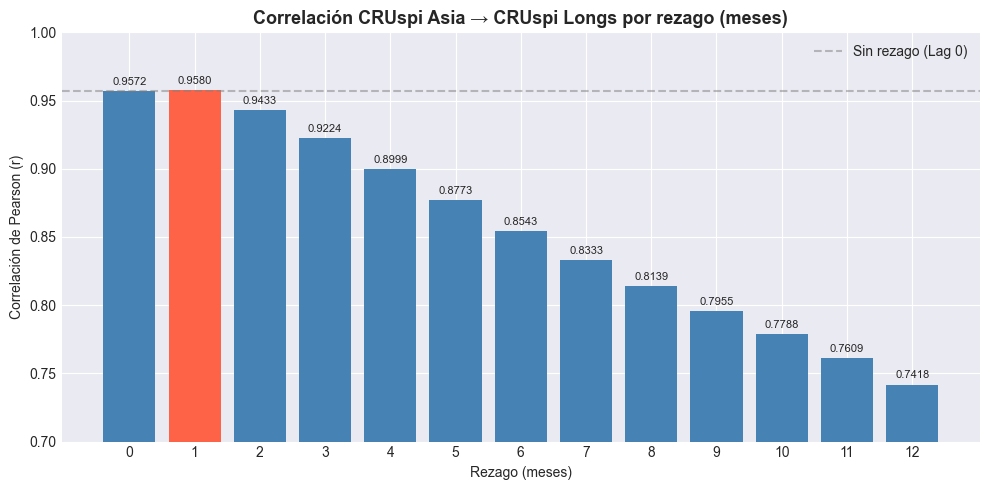

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(lags, correlaciones,
              color=['tomato' if i == lag_optimo else 'steelblue' for i in lags])

ax.set_title('Correlación CRUspi Asia → CRUspi Longs por rezago (meses)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Rezago (meses)')
ax.set_ylabel('Correlación de Pearson (r)')
ax.set_xticks(list(lags))
ax.set_ylim(0.70, 1.0)

for bar, r in zip(bars, correlaciones):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{r:.4f}', ha='center', va='bottom', fontsize=8)

ax.axhline(y=correlaciones[0], color='gray', linestyle='--', alpha=0.5, label='Sin rezago (Lag 0)')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/03_rezago.png', dpi=150)
plt.show()

In [13]:
r_sin_lag, _ = stats.pearsonr(df['cruspi_asia'], df['cruspi_longs'])
r_lag1 = correlaciones[1]

print("=" * 50)
print("CONCLUSIONES NOTEBOOK 2")
print("=" * 50)
print(f"\n1. Correlación sin rezago (Lag 0): r = {r_sin_lag:.4f}")
print(f"2. Correlación óptima (Lag {lag_optimo}):    r = {correlaciones[lag_optimo]:.4f}")
print(f"\n→ CRUspi Asia lidera a CRUspi Longs por {lag_optimo} mes.")
print(f"→ Asia puede usarse como señal anticipada de precios de barras estructurales.")
print(f"→ Diferencia de mejora: +{(r_lag1 - r_sin_lag)*100:.2f} puntos porcentuales con Lag 1.")

CONCLUSIONES NOTEBOOK 2

1. Correlación sin rezago (Lag 0): r = 0.9572
2. Correlación óptima (Lag 1):    r = 0.9580

→ CRUspi Asia lidera a CRUspi Longs por 1 mes.
→ Asia puede usarse como señal anticipada de precios de barras estructurales.
→ Diferencia de mejora: +0.08 puntos porcentuales con Lag 1.
